# Setup and Import

In [ ]:
import os
import numpy as np
from matplotlib import pyplot as plt
import random 
import pandas as pd
import tifffile as tiff
import gc
import rasterio
import tempfile
from sklearn.cluster import KMeans #, AgglomerativeClustering, DBSCAN, HDBSCAN
from sklearn.neighbors import KernelDensity
from scipy.signal import argrelextrema
from scipy import stats
from osgeo import gdal
from rasterio.shutil import copy

# Globals

## Constants and paths

Configuration for this step: which municipality (`procom`), vegetation index and flight year to process, the NoData conventions used on input (`-20`, from step 1) and output (`255`), and the input/output paths under `output/<procom>/`. The input file is the city-wide mosaic produced by step 1 (crop + evaluate indices + mosaic), e.g. `Ventotene-059033-NDVI_red-2022.tif`.

In [2]:
random_state = 1234 #1234
input_nodata_value = -20   # NoData value used by step 1 for the index rasters
mask_nodata_value = 255    # NoData value to use for the output classification masks
seq_size = 100000000
pxl_area = 0.04 # in m^2; pixel size = 20 cm = 0.2 m
save_output_masks = True
index = 'NDVI_red'  # NDVI_red; ENDVI; NDVI_blue
procom = "059033"
city_dict = {'039014': 'Ravenna', 
             '065116': 'Salerno', 
             '031007': 'Gorizia', 
             '038008': 'Ferrara', 
             '051002': 'Arezzo', 
             '048017': 'Firenze',
             '010025': 'Genova',
             '037006': 'Bologna',
             '032006': 'Trieste',
             '015146': 'Milano',
             '063049': 'Napoli',
             '082053': 'Palermo',
             '001272': 'Torino',
             '092009': 'Cagliari',
             '058091': 'Roma',
             '027042': 'Venezia',
             '080063': 'Reggio Calabria',
             '087015': 'Catania',
             '083048': 'Messina',
             '059033': 'Ventotene'}
city_name = city_dict[procom]
flight_year = '2023'

# Input file produced by step 1 (crop + evaluate indices + mosaic), e.g.:
# C:\Users\UTENTE\Downloads\JOS_areeverdi\output\059033\Ventotene_d1-059033-NDVI_red-2022.tif
# This is the city-wide mosaic (step 1 deletes the intermediate per-tile files
# once the mosaic has been written), not a per-tile raster.
indices_file_name = city_name + '-' + procom + '-' + index + '-' + flight_year + '.tif'

show_images = True
frac=0.01 # 0.01
centroids_init = 'kde_maxima' #'kde_maxima' # 'kde_maxima', 'evaluated_4', 'random_4, random_2, ravenna_assessment'

# All inputs/outputs for this procom live under output/<procom>/
#base_path = "C:/Users/UTENTE/Downloads/JOS_areeverdi/"
base_path = "C:/Users/lancioni/istat/DCME/earth observation/verde urbano/codice_JOS/VerdeUrbanoDaOrtofoto/"
output_path = base_path + "output/" + procom + "/"

print('output_path: ', output_path)

output_path:  C:/Users/lancioni/istat/DCME/earth observation/verde urbano/codice_JOS/VerdeUrbanoDaOrtofoto/output/059033/


In [3]:
print(index)
print(procom)
print(city_name)
print(flight_year)
print(indices_file_name)

NDVI_red
059033
Ventotene
2023
Ventotene-059033-NDVI_red-2023.tif


## Functions

I/O and export helpers used throughout the notebook:

- `read_geotiff` / `read_geotiff_as_ndarray`: open a GeoTIFF with GDAL, optionally as a plain numpy array.
- `memory_map`: fallback loader for very large, compressed rasters that don't fit comfortably in RAM — decompresses to a temp file and memory-maps it instead of loading it whole.
- `load_mosaic`: generic loader that dispatches on file extension (`.tif`, `.npy`, `.npz`).
- `write_compressed_mask`: legacy writer (fixed NoData = -9999), kept for reference but not used below.
- `write_compressed_mask_with_nodata`: the writer actually used to export the KDE/KMeans classification masks — writes a compressed, tiled, Byte GeoTIFF block by block, declaring the given NoData value on the output band.

In [4]:

def read_geotiff(filename):
    ds = gdal.Open(filename)
    return ds

def read_geotiff_as_ndarray(filename):
    ds = gdal.Open(filename)
    band = ds.GetRasterBand(1)
    arr = band.ReadAsArray()
    return arr

def memory_map(src_path):
  dst_path = src_path.replace(".tif", "_uncompressed.tif")

  with tempfile.NamedTemporaryFile(suffix=".tif", delete=True) as tmp:
    with rasterio.open(src_path) as src:
        profile = src.profile
        profile.update(
            compress='none',
            tiled=False
        )
        copy(src, dst_path, **profile)   

  return tiff.memmap(dst_path)

def load_mosaic(path_to_mosaic, mosaic_file_name):
    ext = os.path.splitext(mosaic_file_name)[1][1:]
    print(ext)
    if ext == 'tif':
        print('Loading GeoTiff file')
        try:
            mosaic_array = read_geotiff_as_ndarray(os.path.join(path_to_mosaic, mosaic_file_name))
        except:
            mosaic_array = memory_map(os.path.join(path_to_mosaic, mosaic_file_name))
            
    elif ext == 'npy':
        print('Loading ndarray')
        mosaic_array = np.load(os.path.join(path_to_mosaic, mosaic_file_name))
    elif ext == 'npz':
        ds = np.load(os.path.join(path_to_mosaic, mosaic_file_name))
        mosaic_array = ds["array"]
        del ds
        gc.collect()

    return mosaic_array, ext

def write_compressed_mask(mask_file_name, mask_array, ds_mask):
    rows, cols = mask_array.shape
    driver = gdal.GetDriverByName("GTiff")
    ds = driver.Create(
        mask_file_name,
        cols,
        rows,
        1,
        gdal.GDT_Byte,
        options=[
            "COMPRESS=ZSTD",
            "ZSTD_LEVEL=9",
            "PREDICTOR=2",
            "TILED=YES",
            "BIGTIFF=YES",
            "BLOCKXSIZE=512",
            "BLOCKYSIZE=512",
            "NUM_THREADS=ALL_CPUS"
        ]
    )
    ds.SetProjection(ds_mask.GetProjection())
    ds.SetGeoTransform(ds_mask.GetGeoTransform())
    band = ds.GetRasterBand(1)
    band.SetNoDataValue(-9999)
    band.WriteArray(mask_array)
    band.FlushCache()
    ds = None
    print("GeoTIFF saved.")

def write_compressed_mask_with_nodata(mask_file_name, mask_array, ds_mask, mask_nodata_value=255):
    """
    Writes mask_array (already containing mask_nodata_value wherever the source
    pixel was NoData) as a compressed Byte GeoTIFF, reusing projection/geotransform
    from ds_mask (the source index raster). NoData handling is done upstream, on
    the numpy array itself (see the classification cells above), so this function
    just needs to declare the NoData value on the output band and write blockwise.
    """
    rows, cols = mask_array.shape

    driver = gdal.GetDriverByName("GTiff")
    ds = driver.Create(
        mask_file_name, 
        cols, 
        rows, 
        1, 
        gdal.GDT_Byte, 
        options=[
            "COMPRESS=ZSTD",
            "ZSTD_LEVEL=9",
            "PREDICTOR=2",
            "TILED=YES",
            "BIGTIFF=YES",
            "BLOCKXSIZE=512",
            "BLOCKYSIZE=512",
            "NUM_THREADS=ALL_CPUS"
        ]
    )
    
    # Copy georeferencing (projection + geotransform) from the source index raster
    ds.SetProjection(ds_mask.GetProjection())
    ds.SetGeoTransform(ds_mask.GetGeoTransform())
    
    band = ds.GetRasterBand(1)
    band.SetNoDataValue(mask_nodata_value)
    
    # Write block by block (512x512 pixels at a time) to keep peak memory low
    block_size = 512
    mask_array_u8 = mask_array.astype(np.uint8)

    for y in range(0, rows, block_size):
        y_size = min(block_size, rows - y)
        for x in range(0, cols, block_size):
            x_size = min(block_size, cols - x)
            out_block = mask_array_u8[y:y+y_size, x:x+x_size]
            band.WriteArray(out_block, x, y)

    # Close and flush to disk
    band.FlushCache()
    ds = None
    print("GeoTIFF successfully saved block by block: ", mask_file_name)

# Data

## Loading saved indices

Loads the index raster produced by step 1/2 (`indices_file_name`) into memory as a numpy array. `load_mosaic` dispatches on file extension and falls back to a memory-mapped read if the file is too large/compressed to load directly.

In [5]:
indices_values_array, ext = load_mosaic(output_path, indices_file_name)
print(indices_file_name)
print(indices_values_array.shape)
print(indices_values_array.dtype)

tif
Loading GeoTiff file
Ventotene-059033-NDVI_red-2023.tif
(6526, 5309)
float32


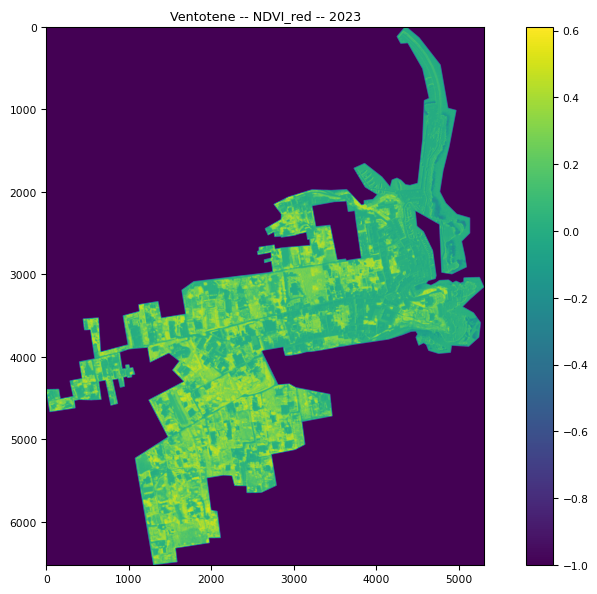

In [6]:
if show_images:
    title = str(city_name) + ' -- ' + index + ' -- ' + flight_year
    tiff.imshow(np.where((indices_values_array >= -1.0) & (indices_values_array <= 1.0),indices_values_array,-1))
    plt.title(title)
    plt.show()

## Histograms

### Sampling and cutting original data

The dataset of the indices is sampled taking a random fraction ```frac=0.01``` 


Further, to avoid no-data values (pixels outside loc1), only values with ```indices != -20``` are taken.

In [7]:
try:
    x, y = indices_values_array.shape
except:
    _, x, y = indices_values_array.shape
indices_flatten = np.reshape(indices_values_array, (x*y))
tot_seq = indices_flatten.shape[0]
print(indices_flatten.shape)
print(indices_flatten.dtype)
del indices_values_array
gc.collect()

(34646534,)
float32


6339

In [8]:
tot_pxl = 0
k=1

indices_flatten_frac = np.empty([1]).astype(np.float32)
for i in range(0, tot_seq, seq_size):
    print('tile ' + str(k) + ': ' + str(i))
    if np.any(indices_flatten[i:i+seq_size]):
        np.random.seed(random_state)
        ind_loc1 = indices_flatten[i:i+seq_size]
        # keep only valid pixels: within the NDVI range and not the NoData value (-20)
        ind_loc1 = ind_loc1[(ind_loc1 >= -1.0) & (ind_loc1 <= 1.0) & (ind_loc1 != input_nodata_value)]
        tot_pxl += ind_loc1.shape[0]
        ind_loc1_frac = np.random.choice(ind_loc1, size=int(ind_loc1.shape[0]*frac), replace=False)
        indices_flatten_frac = np.concatenate((indices_flatten_frac, ind_loc1_frac))
        del ind_loc1
        del ind_loc1_frac
        gc.collect()
    else:
        print('Empty tile')
        print(indices_flatten[i:i+seq_size].shape)
    k+=1

#delete first element
indices_flatten_frac = indices_flatten_frac[1:]
indices_flatten_frac = np.reshape(indices_flatten_frac, (-1,1))
print(indices_flatten_frac.shape)
print(indices_flatten_frac.dtype)

tile 1: 0
(96474, 1)
float32


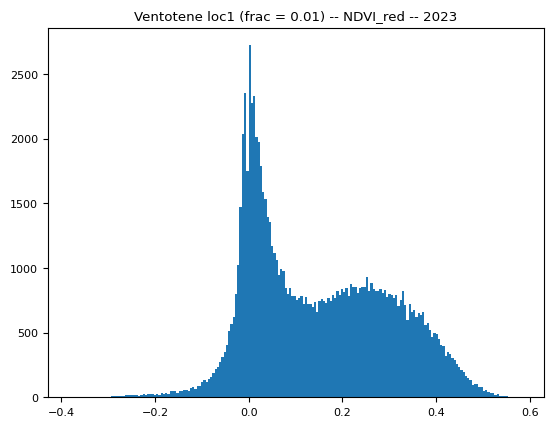

In [9]:
plt.hist(indices_flatten_frac, bins=200)
plt.title(city_name + ' loc1 (frac = ' + str(frac) + ') -- ' + index + ' -- ' + flight_year)
plt.show()

### KDE
Reference: [KDE with sklearn](https://scikit-learn.org/stable/modules/density.html#kernel-density)

#### Rule-of-thumb for ```band_width```
This is the well known approximation termed as the _normal distribution approximation_, _Gaussian approximation_, or _Silverman's rule of thumb_.

In [10]:
a = indices_flatten_frac
n = indices_flatten_frac.shape[0]
a_std = np.std(a)
print(a_std)
b = np.sort(a, axis=0)
b_iqr = stats.iqr(b, interpolation='midpoint')
#h = 1.06 * np.min(np.array([a_std, b_iqr])) * (n**(-0.2))
h = 0.9 * np.min(np.array([a_std, b_iqr/1.349])) * (n**(-0.2))
print(b_iqr)
print(h)

del a
del b
gc.collect()

0.14950986
0.25247617810964584
0.01355283943531949


14978

#### Density Estimation

In [11]:
kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(np.where(indices_flatten_frac == 1.0,0.0,indices_flatten_frac).astype(np.float16))  # 0.005
print(kde.get_params())

{'algorithm': 'auto', 'atol': 0, 'bandwidth': 0.01355283943531949, 'breadth_first': True, 'kernel': 'gaussian', 'leaf_size': 40, 'metric': 'euclidean', 'metric_params': None, 'rtol': 0}


#### Searching for max and min in density 

In [12]:
s = np.linspace(-1,1)
e = kde.score_samples(s.reshape(-1,1))
mi, ma = argrelextrema(e, np.less)[0], argrelextrema(e, np.greater)[0]
print("Minima:", s[mi])
print("Maxima:", s[ma])

Minima: [0.14285714]
Maxima: [0.02040816 0.26530612]


2723.0
4.106477448014003


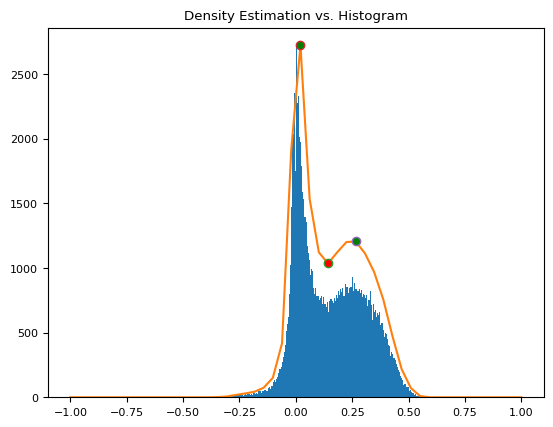

In [13]:
n, bins, _ = plt.hist(indices_flatten_frac, bins=200)
hist_max = np.max(n)
print(hist_max)
dens_max = np.max(np.exp(e[ma]))
print(dens_max)
f = hist_max/dens_max
plt.plot(s, np.exp(e)*f)
for i in range(s[mi].shape[0]):
    plt.plot(s[mi][i], np.exp(e[mi[i]])*f, marker="o", markerfacecolor="red")
for i in range(s[ma].shape[0]):
    plt.plot(s[ma][i], np.exp(e[ma[i]])*f, marker="o", markerfacecolor="green")
plt.title('Density Estimation vs. Histogram')
plt.show()

#### Filtering Maxima and Minima
Some small, random concentrations of pixels may be considered by KDE as maxima or minima. These points are to be romoved since they bias true thresholds.

For this reason we apply a scale factor _wrt_ the absolute maximum. This is a heuristic; for what follows we put it ```= 1/40```



In [14]:
euristic_scale_factor = 40.0  # this is a magic number
kde_filter = np.max(np.exp(e[ma])) / euristic_scale_factor
print('kde_filter: ', kde_filter)
kde_min = s[mi]
kde_min = kde_min[np.exp(e[mi])>kde_filter]
print("Filtered Minima:", kde_min)
kde_max = s[ma]
kde_max = kde_max[np.exp(e[ma])>kde_filter]
print("Filtered Maxima:", kde_max)

kde_filter:  0.10266193620035007
Filtered Minima: [0.14285714]
Filtered Maxima: [0.02040816 0.26530612]


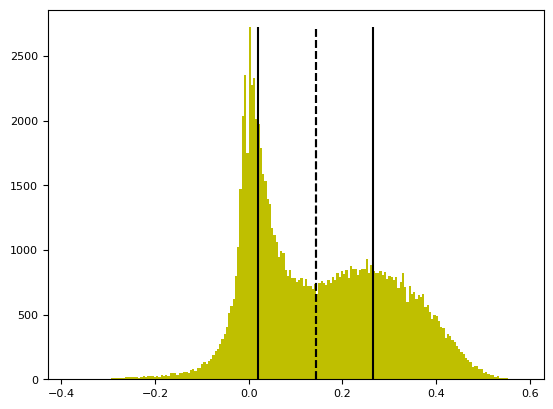

In [15]:
n, _, _ = plt.hist(indices_flatten_frac, bins=200, color='y')
for i in range(len(kde_max)):
    plt.vlines(x=kde_max[i],ymin=0.,ymax=max(n), colors='k')
    try:
        plt.vlines(x=kde_min[i-1],ymin=0.,ymax=max(n), linestyles='dashed', colors='k')
    except:
        print()
plt.show()

### KMeans

In [16]:
print(centroids_init)
if centroids_init == 'evaluated_4':
    if len(kde_max)==1:
        #uno prima di zero e due dopo
        print('One only max; add 3 centroid')
        max_0 = -0.5
        max_2 = (1.0 + kde_max[0])/3
        max_3 = 2*(1.0 + kde_max[0])/3
        kde_max = np.concatenate((kde_max,[max_0],[max_2],[max_3]))
    elif len(kde_max)==2:
        #uno prima del primo e uno dopo l'ultimo
        print('Only 2 max; add 2 centroid')
        max_0 = -0.5
        max_3 = (1.0 + kde_max[-1])/2
        kde_max = np.concatenate((kde_max,[max_0],[max_3]))
    elif len(kde_max)==3:
        #uno dopo l'ultimo 
        print('Only 3 max; add 1 centroid')
        max_3 = (1.0 + kde_max[-1])/2
        kde_max = np.concatenate((kde_max,[max_3]))
elif centroids_init == 'random_2':
    if len(kde_max)==1:
        second_max = random.uniform(kde_max[-1], 1.0)
        kde_max = np.concatenate((kde_max,[second_max]))
elif centroids_init == 'ravenna_assessment':
    second_max = random.uniform(kde_max[0], 1.0)
    kde_max = np.concatenate(([kde_max[0]],[second_max]))
elif centroids_init == 'kde_maxima' and len(kde_max)<=1:
    #se un solo max aggiungo comunque uno (vecchia gestione)
    second_max = (1.0 + kde_max[0])/2
    kde_max = np.concatenate((kde_max,[second_max]))
print(kde_max)
print(kde_max.shape)

kde_maxima
[0.02040816 0.26530612]
(2,)


In [17]:
kde_max[0]

0.020408163265306145

In [18]:
centroids = np.expand_dims(kde_max, axis=1)
print(centroids)

[[0.02040816]
 [0.26530612]]


In [19]:

if centroids_init == 'random_4':
    n_clusters=4
    kmeans = KMeans(n_clusters=n_clusters, init='random', n_init=10, random_state=random_state)
else:
    n_clusters=len(kde_max)
    kmeans = KMeans(n_clusters=n_clusters, init=centroids,n_init=10, random_state=random_state)

kmeans.fit(indices_flatten_frac)

C:\Users\lancioni\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:1412: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=10.
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(init=array([[0.02040816],
       [0.26530612]]), n_clusters=2, n_init=10,
       random_state=1234)

In [20]:
kmeans.get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': array([[0.02040816],
        [0.26530612]]),
 'max_iter': 300,
 'n_clusters': 2,
 'n_init': 10,
 'random_state': 1234,
 'tol': 0.0001,
 'verbose': 0}

In [21]:
print("Cluster centers:\n{}".format(kmeans.cluster_centers_))
print("Cluster memberships:\n{}".format(kmeans.labels_))

Cluster centers:
[[0.03376546]
 [0.2956937 ]]
Cluster memberships:
[1 0 1 ... 0 0 0]


In [22]:
cl_min = []
cl_max = []
for i in range(kmeans.labels_.max()+1):
    print(i)
    cl_min.append(indices_flatten_frac[kmeans.labels_==i].min())
    cl_max.append(indices_flatten_frac[kmeans.labels_==i].max())

0
1


In [23]:
cl_min.sort()
cl_max.sort()
print('Clusters limits:')
for i in range(len(cl_min)):
    print(str(i) + '| min: ' + str(cl_min[i]) + '; max: ' + str(cl_max[i]))

Clusters limits:
0| min: -0.38064516; max: 0.16470589
1| min: 0.16475096; max: 0.58196723


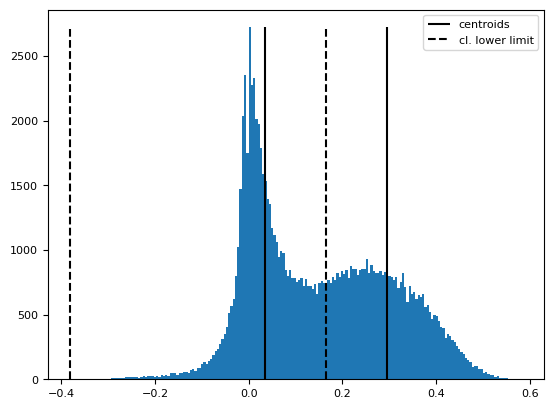

In [24]:
n, _, _ = plt.hist(indices_flatten_frac, bins=200)
plt.vlines(x=kmeans.cluster_centers_,ymin=0.,ymax=max(n), colors='k')
plt.vlines(x=cl_min,ymin=0.,ymax=max(n), linestyles='dashed', colors='k')
plt.legend(['centroids','cl. lower limit'])
plt.show()

In [25]:
del indices_flatten_frac
del s
del e
del kde
del kmeans
gc.collect()

30790

## Classification: KDE mask and KMeans mask

Two independent binary vegetation masks are produced from the full-resolution index raster (`indices_flatten`), each with its own threshold:

- **KDE threshold**: the last filtered antimode found above (`kde_min[-1]`), i.e. the valley of the density estimate that separates the "non-vegetation" mode from the "vegetation" mode.
- **KMeans threshold**: the lower bound of the top ("vegetation") cluster found by KMeans (`cl_min[-1]`).

For both masks, a pixel is classified as:
- `1` (vegetation) if `index value >= threshold`
- `0` (non-vegetation) otherwise
- `mask_nodata_value` (255) if the input pixel was NoData (`input_nodata_value = -20`), regardless of the threshold

Processing is done in chunks of `seq_size` elements (same tiling strategy used for sampling above) to bound peak memory usage. Elapsed time is measured separately for each method (`kde_elab_time`, `kmeans_elab_time`) and reported in the stats/CSV export below.

In [26]:
# KMeans threshold: lower bound of the top ("vegetation") cluster found by KMeans
kmeans_threshold = cl_min[-1]

# KDE threshold: last filtered antimode (minimum) found by KDE, i.e. the valley
# between the "non-vegetation" and "vegetation" modes of the density estimate
kde_threshold = kde_min[-1]

print('KMeans threshold: ', kmeans_threshold)
print('KDE threshold:    ', kde_threshold)

kmeans_mask = np.empty_like(indices_flatten, dtype=np.int16)
kde_mask = np.empty_like(indices_flatten, dtype=np.int16)

k=1
n_pxl_kde = 0
for i in range(0, tot_seq, seq_size):
    print('tile ' + str(k) + ': ' + str(i))
    chunk = indices_flatten[i:i+seq_size]
    if np.any(chunk):
        valid = (chunk != input_nodata_value)

        # KDE-based classification: 1 = vegetation, 0 = non-vegetation, nodata preserved
        kde_chunk = np.where(chunk >= kde_threshold, 1, 0).astype(np.int16)
        kde_chunk[~valid] = mask_nodata_value
        kde_mask[i:i+seq_size] = kde_chunk
        n_pxl_kde += np.sum(kde_chunk == 1, dtype=np.int64)

        print('KDE green px so far: ', n_pxl_kde)
        del kde_chunk, valid
        gc.collect()
    else:
        print('Empty tile')
        print(chunk.shape)
    k+=1

k=1
n_pxl_kmeans = 0
for i in range(0, tot_seq, seq_size):
    print('tile ' + str(k) + ': ' + str(i))
    chunk = indices_flatten[i:i+seq_size]
    if np.any(chunk):
        valid = (chunk != input_nodata_value)

        # KMeans-based classification: 1 = vegetation, 0 = non-vegetation, nodata preserved
        km_chunk = np.where(chunk >= kmeans_threshold, 1, 0).astype(np.int16)
        km_chunk[~valid] = mask_nodata_value
        kmeans_mask[i:i+seq_size] = km_chunk
        n_pxl_kmeans += np.sum(km_chunk == 1, dtype=np.int64)

        print('KMeans green px so far: ', n_pxl_kmeans)
        del km_chunk, valid
        gc.collect()
    else:
        print('Empty tile')
        print(chunk.shape)
    k+=1

kmeans_mask = np.reshape(kmeans_mask, (x, y))
kde_mask = np.reshape(kde_mask, (x, y))

print(kmeans_mask.shape, kmeans_mask.dtype)
print(kde_mask.shape, kde_mask.dtype)

KMeans threshold:  0.16475096
KDE threshold:     0.1428571428571428
tile 1: 0
KDE green px so far:  4556477
tile 1: 0
KMeans green px so far:  4209685
(6526, 5309) int16
(6526, 5309) int16


# Stats

Builds a summary table with one row per method (KDE, KMeans), reporting: threshold used, total valid pixels, classified vegetation pixels/percentage/area (m² and ha), and elapsed classification time. This table (`data_fr`) is later exported as the CSV in the Export section below.

In [27]:
# Elapsed time per method, measured right after each classification block above.
# (kde_elab_time/kmeans_elab_time are set in the classification cell.)
methods = ['KDE', 'KMeans (' + str(n_clusters) + ' clusters)']
thresholds = [kde_threshold, kmeans_threshold]
green_pxls = [n_pxl_kde, n_pxl_kmeans]

rows = []
for method, thr, n_pxl in zip(methods, thresholds, green_pxls):
    perc = n_pxl / tot_pxl * 100
    m_2 = n_pxl * pxl_area
    ha = m_2 * 1e-4
    rows.append({
        'city': procom + ' ' + city_name,
        'method': method,
        'fl. year': flight_year,
        'index': index,
        'thres.': thr,
        'tot pix.': tot_pxl,
        'green pix.': n_pxl,
        'green %': perc,
        'green m^2': m_2,
        'green ha': ha
    })

data_fr = pd.DataFrame(rows)
display(data_fr)

,city,method,fl. year,index,thres.,tot pix.,green pix.,green %,green m^2,green ha
0,059033 Ventotene,KDE,2023,NDVI_red,0.142857,9647428,4556477,47.229966,182259.08,18.225908
1,059033 Ventotene,KMeans (2 clusters),2023,NDVI_red,0.164751,9647428,4209685,43.635309,168387.40,16.838740


# Export

Writes the outputs of this step, all into `output_path` (`output/<procom>/`):

- `<city_name>-<procom>-<index>-<flight_year>--KMeans_mask.tif` — binary vegetation mask from the KMeans threshold (only if `save_output_masks` is `True`).
- `<city_name>-<procom>-<index>-<flight_year>--KDE_mask.tif` — binary vegetation mask from the KDE threshold (only if `save_output_masks` is `True`).
- `<city_name>-<procom>-<index>-<flight_year>.csv` — summary stats table (always written), matching the format of the reference CSV (`;`-separated, comma as decimal separator).

Both mask GeoTIFFs are Byte rasters (`0` = non-vegetation, `1` = vegetation, `255` = NoData), reusing the projection and geotransform of the source index raster.

In [28]:
if save_output_masks:
    ds_1 = read_geotiff(os.path.join(output_path, indices_file_name))
    print(ds_1.GetProjection())
    print(ds_1.GetGeoTransform())
    print('KMeans mask shape: ', kmeans_mask.shape)
    print('KDE mask shape:    ', kde_mask.shape)

PROJCS["RDN2008 / UTM zone 33N",GEOGCS["RDN2008",DATUM["Rete_Dinamica_Nazionale_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1132"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","6706"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","7792"]]
(366955.1456853751, 0.2, 0.0, 4518024.42108661, 0.0, -0.2)
KMeans mask shape:  (6526, 5309)
KDE mask shape:     (6526, 5309)


In [29]:
if save_output_masks:
    kmeans_mask_name = city_name + '-' + procom + '-' + index + '-' + flight_year + '--KMeans_mask.tif'
    kde_mask_name = city_name + '-' + procom + '-' + index + '-' + flight_year + '--KDE_mask.tif'

    write_compressed_mask_with_nodata(os.path.join(output_path, kmeans_mask_name), kmeans_mask, ds_1, mask_nodata_value)
    write_compressed_mask_with_nodata(os.path.join(output_path, kde_mask_name), kde_mask, ds_1, mask_nodata_value)

# CSV with the summary stats (KDE + KMeans) -- always written, independently of
# save_output_masks, matching the format/columns of the reference file
# (city_name-procom-index-year.csv): ';' separator, ',' as decimal separator,
# unnamed leading index column.
csv_name = city_name + '-' + procom + '-' + index + '-' + flight_year + '.csv'
csv_path = os.path.join(output_path, csv_name)
data_fr.to_csv(csv_path, sep=';', decimal=',', index=True)
print('CSV saved: ', csv_path)

GeoTIFF successfully saved block by block:  C:/Users/lancioni/istat/DCME/earth observation/verde urbano/codice_JOS/VerdeUrbanoDaOrtofoto/output/059033/Ventotene-059033-NDVI_red-2023--KMeans_mask.tif
GeoTIFF successfully saved block by block:  C:/Users/lancioni/istat/DCME/earth observation/verde urbano/codice_JOS/VerdeUrbanoDaOrtofoto/output/059033/Ventotene-059033-NDVI_red-2023--KDE_mask.tif
CSV saved:  C:/Users/lancioni/istat/DCME/earth observation/verde urbano/codice_JOS/VerdeUrbanoDaOrtofoto/output/059033/Ventotene-059033-NDVI_red-2023.csv
